# 04 — Performance Analytics
**Bluestock Fintech Capstone**

Covers:
1. Imports & data load
2. Absolute return analysis (1Y / 3Y / 5Y)
3. Benchmark-adjusted alpha & excess return
4. Beta & market sensitivity (OLS regression)
5. Risk metrics — Sharpe, Sortino, Max Drawdown, Calmar
6. Rolling performance — 90-day rolling Sharpe & return
7. NAV CAGR heatmap across schemes
8. Expense ratio drag analysis
9. Regular vs Direct plan comparison
10. Category-level performance ranking
11. Performance consistency — win-rate analysis
12. Summary league table

---
## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 50)
print("Libraries loaded ✅")

Libraries loaded ✅


---
## Cell 2 — Load Data

In [2]:
nav         = pd.read_csv("../data/processed/nav_history_clean.csv", parse_dates=["date"])
performance = pd.read_csv("../data/processed/performance_clean.csv", parse_dates=["launch_date"])
benchmark   = pd.read_csv("../data/raw/10_benchmark_indices.csv", parse_dates=["date"])
fund_master = pd.read_csv("../data/raw/01_fund_master.csv", parse_dates=["launch_date"])

# Pivot benchmark to wide format — one column per index
bench_wide = benchmark.pivot_table(index="date", columns="index_name", values="close_value")
bench_wide.columns.name = None

# Compute daily benchmark returns
bench_returns = bench_wide.pct_change().mul(100)

print("Datasets loaded:")
print(f"  nav            : {nav.shape}")
print(f"  performance    : {performance.shape}")
print(f"  benchmark wide : {bench_wide.shape}")
print(f"  fund_master    : {fund_master.shape}")
print(f"\nBenchmark indices: {list(bench_wide.columns)}")
print(f"Date range: {nav['date'].min().date()} → {nav['date'].max().date()}")

Datasets loaded:
  nav            : (46000, 10)
  performance    : (40, 27)
  benchmark wide : (1150, 7)
  fund_master    : (40, 15)

Benchmark indices: ['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100', 'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150']
Date range: 2022-01-03 → 2026-05-29


---
## 3 — Absolute Return Analysis

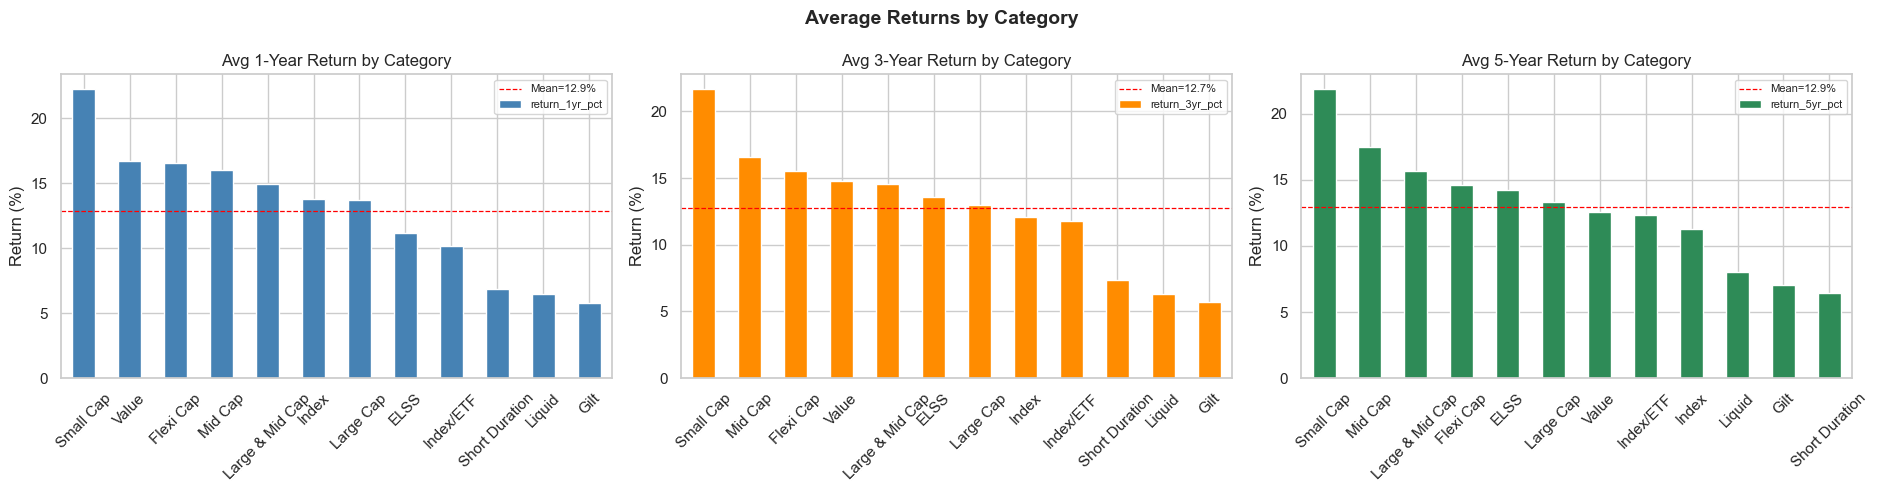

In [3]:
# 3a. Return bar charts — 1Y / 3Y / 5Y grouped by category
ret_cols = ["return_1yr_pct", "return_3yr_pct", "return_5yr_pct"]
labels   = ["1-Year", "3-Year", "5-Year"]
colors   = ["steelblue", "darkorange", "seagreen"]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, col, label, color in zip(axes, ret_cols, labels, colors):
    data = performance.groupby("category")[col].mean().sort_values(ascending=False)
    data.plot(kind="bar", ax=ax, color=color, edgecolor="white")
    ax.set_title(f"Avg {label} Return by Category")
    ax.set_xlabel("")
    ax.set_ylabel("Return (%)")
    ax.axhline(data.mean(), color="red", linestyle="--", linewidth=0.9,
               label=f"Mean={data.mean():.1f}%")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Average Returns by Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

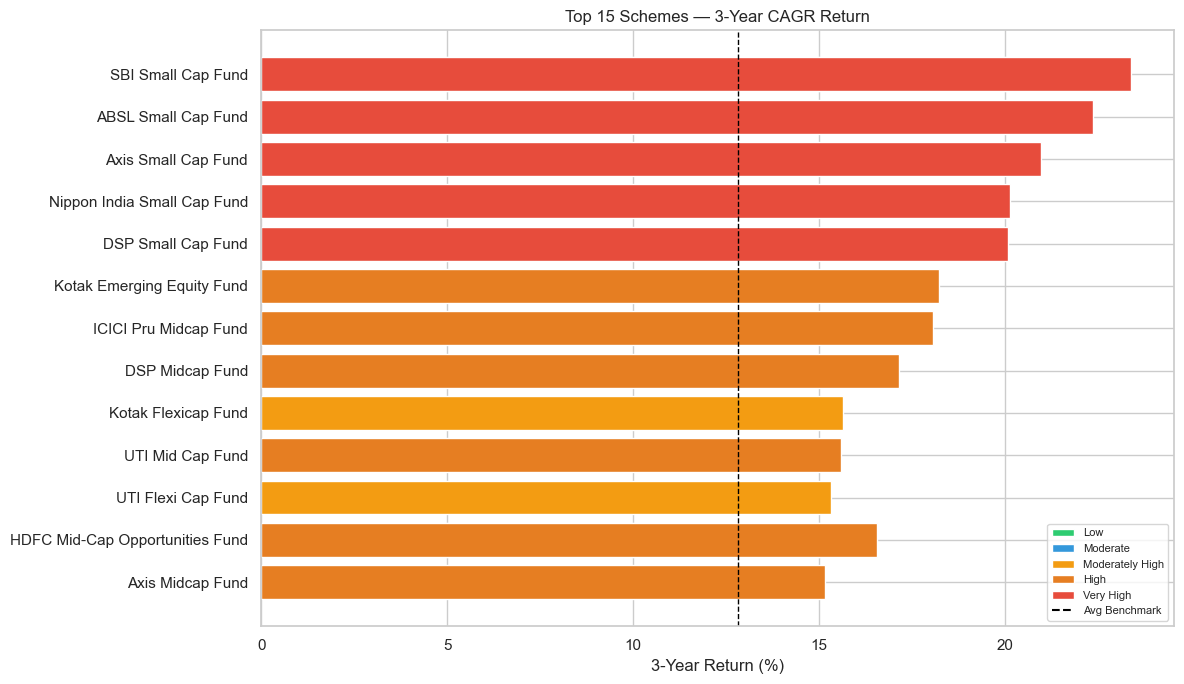

In [4]:
# 3b. Individual scheme returns — top 15 by 3-year return
top15 = performance.nlargest(15, "return_3yr_pct").sort_values("return_3yr_pct")
colors_risk = {"Low":"#2ecc71", "Moderate":"#3498db",
               "Moderately High":"#f39c12", "High":"#e67e22",
               "Very High":"#e74c3c"}

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = [colors_risk.get(r, "gray") for r in top15["risk_grade"]]
bars = ax.barh(top15["scheme_name"].str.split(" - ").str[0],
               top15["return_3yr_pct"], color=bar_colors, edgecolor="white")
ax.axvline(performance["benchmark_3yr_pct"].mean(), color="black",
           linestyle="--", linewidth=1, label=f"Avg Benchmark ({performance['benchmark_3yr_pct'].mean():.1f}%)")
ax.set_title("Top 15 Schemes — 3-Year CAGR Return", fontsize=12)
ax.set_xlabel("3-Year Return (%)")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_risk.items()]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0],color='black',linestyle='--',label='Avg Benchmark')],
          loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

---
## 4 — Benchmark-Adjusted Alpha & Excess Return

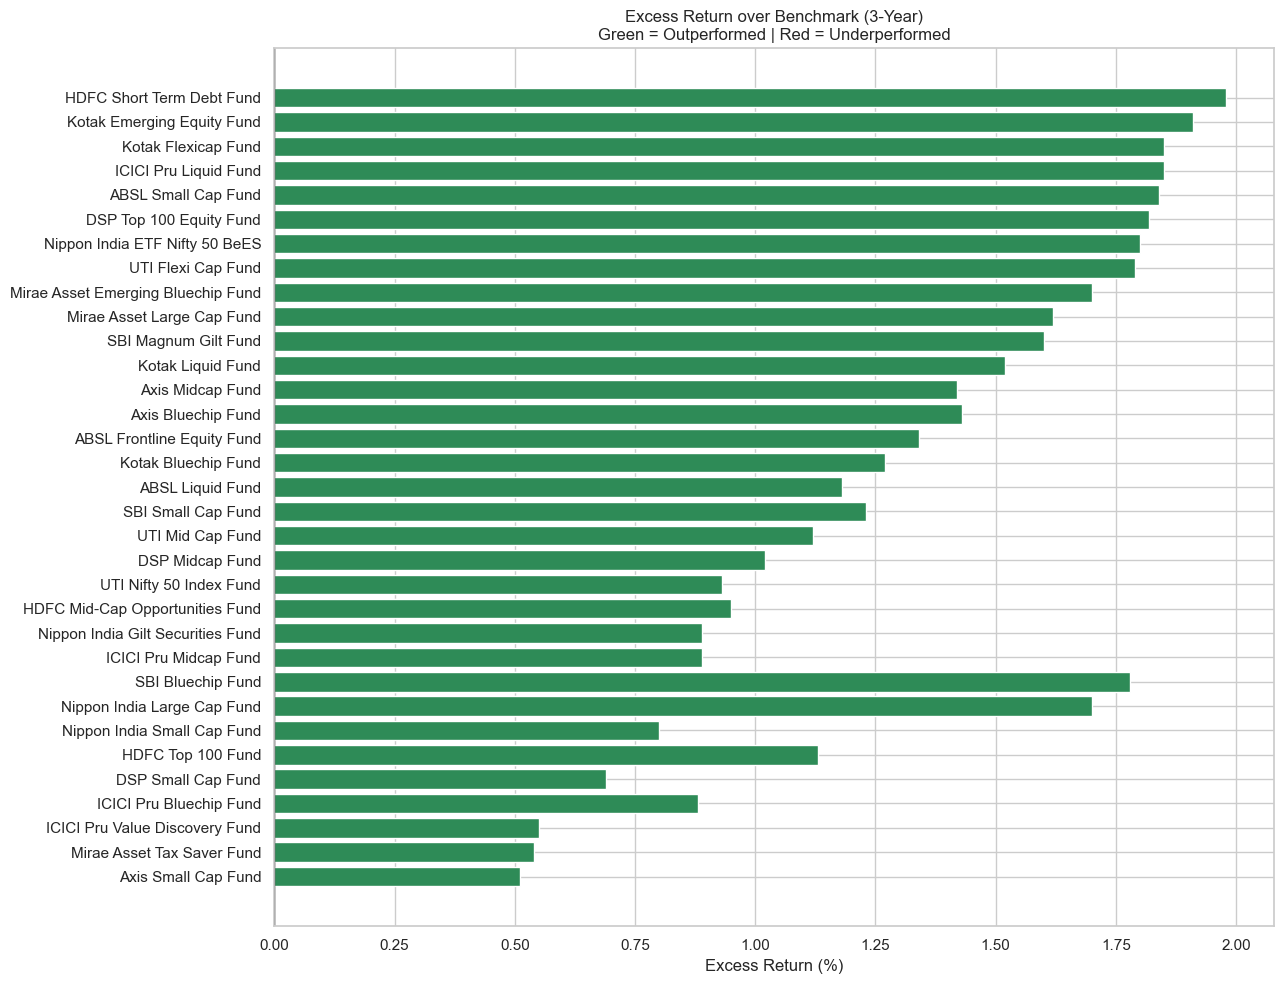


Outperformed benchmark : 40/40 schemes (100%)


In [5]:
# 4a. Excess return over benchmark (3yr) — all schemes
exc = performance.sort_values("excess_return", ascending=True)
bar_c = ["seagreen" if x >= 0 else "crimson" for x in exc["excess_return"]]

fig, ax = plt.subplots(figsize=(13, 10))
ax.barh(exc["scheme_name"].str.split(" - ").str[0],
        exc["excess_return"], color=bar_c, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Excess Return over Benchmark (3-Year)\nGreen = Outperformed | Red = Underperformed",
             fontsize=12)
ax.set_xlabel("Excess Return (%)")
plt.tight_layout()
plt.show()

outperformers = (exc["excess_return"] > 0).sum()
print(f"\nOutperformed benchmark : {outperformers}/{len(exc)} schemes ({outperformers/len(exc)*100:.0f}%)")

C:\Users\chinm\AppData\Local\Temp\ipykernel_21448\3441352631.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=performance, x="category", y="alpha",


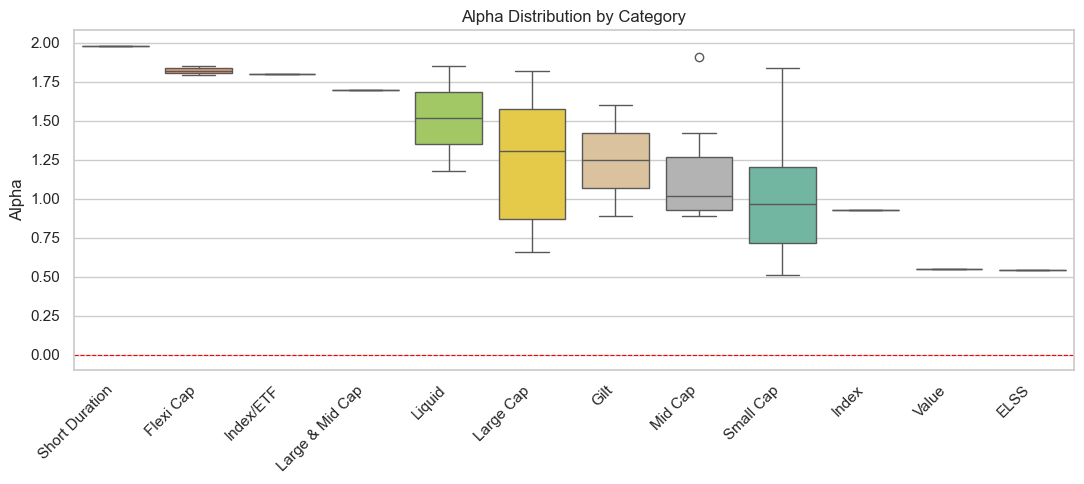

In [6]:
# 4b. Alpha distribution by category
fig, ax = plt.subplots(figsize=(11, 5))
order_alpha = performance.groupby("category")["alpha"].median().sort_values(ascending=False).index
sns.boxplot(data=performance, x="category", y="alpha",
            order=order_alpha, palette="Set2", ax=ax)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Alpha Distribution by Category")
ax.set_xlabel("")
ax.set_ylabel("Alpha")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 5 — Beta & Market Sensitivity (OLS Regression)

In [7]:
# 5a. Compute OLS beta for each scheme vs NIFTY50
nifty_ret = bench_returns[["NIFTY50"]].rename(columns={"NIFTY50": "nifty_ret"})

beta_results = []
for code, grp in nav.groupby("amfi_code"):
    grp = grp.sort_values("date").dropna(subset=["daily_return_pct"])
    merged = grp.merge(nifty_ret, left_on="date", right_index=True, how="inner")
    if len(merged) < 30:
        continue
    slope, intercept, r, p, se = linregress(merged["nifty_ret"], merged["daily_return_pct"])
    scheme_name = grp["scheme_name"].iloc[0]
    category    = grp["category"].iloc[0]
    beta_results.append({
        "amfi_code":    code,
        "scheme_name":  scheme_name,
        "category":     category,
        "ols_beta":     round(slope, 4),
        "ols_alpha":    round(intercept, 6),
        "r_squared":    round(r**2, 4),
        "p_value":      round(p, 6),
    })

beta_df = pd.DataFrame(beta_results)
print(f"OLS beta computed for {len(beta_df)} schemes")
print(beta_df[["scheme_name", "category", "ols_beta", "r_squared"]]
      .sort_values("ols_beta", ascending=False).to_string(index=False))

OLS beta computed for 40 schemes
                                          scheme_name category  ols_beta  r_squared
                DSP Small Cap Fund - Regular - Growth   Equity      0.13       0.00
           SBI Small Cap Fund - Regular Plan - Growth   Equity      0.07       0.00
    ICICI Pru Value Discovery Fund - Regular - Growth   Equity      0.05       0.00
               Kotak Bluechip Fund - Regular - Growth   Equity      0.04       0.00
                UTI Flexi Cap Fund - Regular - Growth   Equity      0.04       0.00
       Nippon India Large Cap Fund - Regular - Growth   Equity      0.04       0.00
        ABSL Frontline Equity Fund - Regular - Growth   Equity      0.03       0.00
            ICICI Pru Bluechip Fund - Direct - Growth   Equity      0.02       0.00
           DSP Top 100 Equity Fund - Regular - Growth   Equity      0.01       0.00
               Axis Small Cap Fund - Regular - Growth   Equity      0.01       0.00
        Nippon India Large Cap Fund - Direc

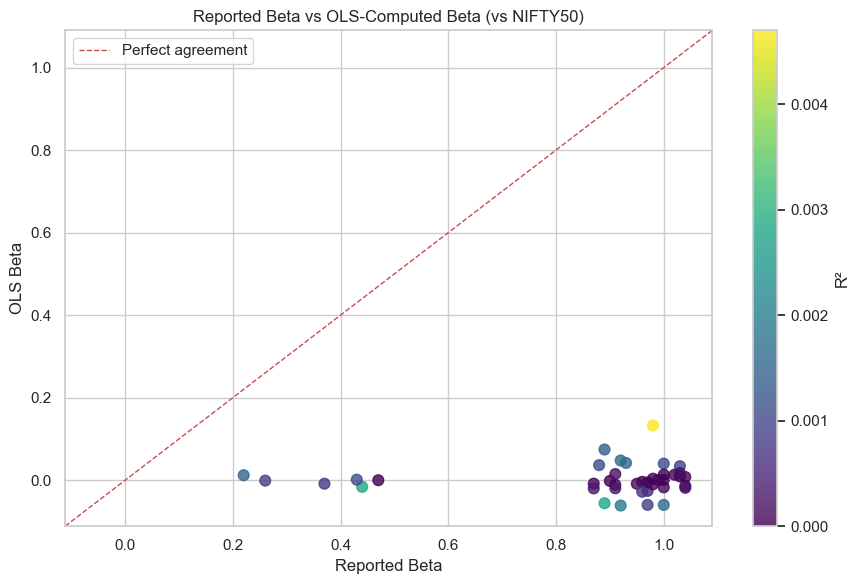

In [8]:
# 5b. Beta comparison — precomputed (from performance) vs OLS
beta_compare = beta_df.merge(
    performance[["amfi_code", "beta", "plan"]].rename(columns={"beta": "reported_beta"}),
    on="amfi_code"
)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(beta_compare["reported_beta"], beta_compare["ols_beta"],
                c=beta_compare["r_squared"], cmap="viridis", s=60, alpha=0.8)
lims = [beta_compare[["reported_beta","ols_beta"]].min().min() - 0.05,
        beta_compare[["reported_beta","ols_beta"]].max().max() + 0.05]
ax.plot(lims, lims, "r--", linewidth=1, label="Perfect agreement")
plt.colorbar(sc, ax=ax, label="R²")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title("Reported Beta vs OLS-Computed Beta (vs NIFTY50)")
ax.set_xlabel("Reported Beta")
ax.set_ylabel("OLS Beta")
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\chinm\AppData\Local\Temp\ipykernel_21448\4167651627.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=beta_df, x="category", y="ols_beta",


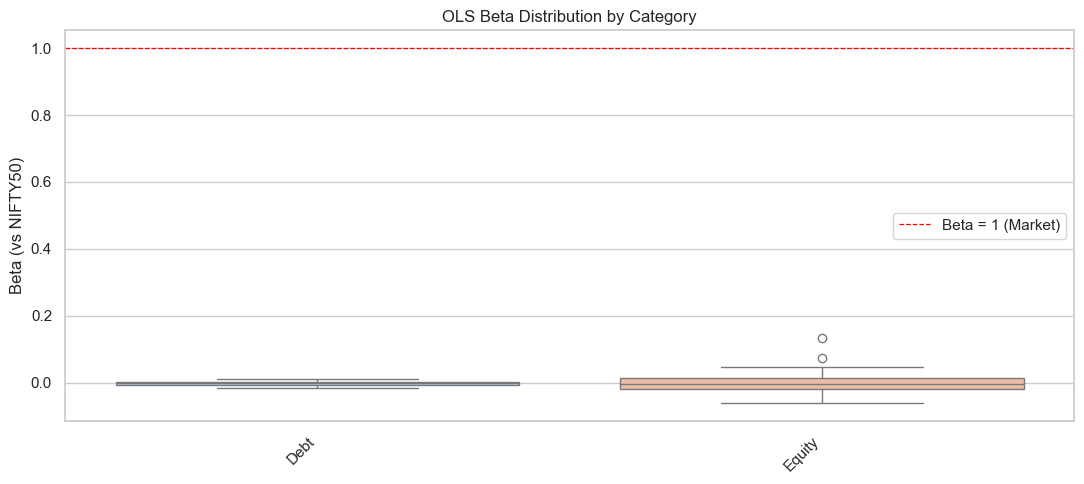

In [9]:
# 5c. Beta by category — boxplot
fig, ax = plt.subplots(figsize=(11, 5))
order_beta = beta_df.groupby("category")["ols_beta"].median().sort_values(ascending=False).index
sns.boxplot(data=beta_df, x="category", y="ols_beta",
            order=order_beta, palette="coolwarm", ax=ax)
ax.axhline(1, color="red", linestyle="--", linewidth=0.9, label="Beta = 1 (Market)")
ax.set_title("OLS Beta Distribution by Category")
ax.set_xlabel("")
ax.set_ylabel("Beta (vs NIFTY50)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 6 — Risk Metrics: Sharpe, Sortino, Max Drawdown, Calmar

In [10]:
# 6a. Compute risk metrics from daily NAV returns
RISK_FREE_DAILY = 6.5 / 252 / 100   # ~6.5% annualised RBI repo rate proxy

risk_metrics = []
for code, grp in nav.groupby("amfi_code"):
    grp = grp.sort_values("date").dropna(subset=["daily_return_pct"])
    r   = grp["daily_return_pct"].values / 100   # as decimal
    if len(r) < 50:
        continue

    # Annualised return
    ann_return = ((1 + r).prod() ** (252 / len(r)) - 1) * 100

    # Sharpe
    excess_r   = r - RISK_FREE_DAILY
    sharpe     = (excess_r.mean() / excess_r.std()) * np.sqrt(252) if excess_r.std() > 0 else np.nan

    # Sortino (downside std only)
    downside   = excess_r[excess_r < 0]
    sortino    = (excess_r.mean() / downside.std()) * np.sqrt(252) if len(downside) > 0 and downside.std() > 0 else np.nan

    # Max Drawdown
    nav_series = grp["nav"].values
    roll_max   = np.maximum.accumulate(nav_series)
    drawdowns  = (nav_series - roll_max) / roll_max * 100
    max_dd     = drawdowns.min()

    # Calmar = Annualised Return / |Max Drawdown|
    calmar     = ann_return / abs(max_dd) if abs(max_dd) > 0 else np.nan

    # Annualised volatility
    ann_vol    = r.std() * np.sqrt(252) * 100

    risk_metrics.append({
        "amfi_code":    code,
        "scheme_name":  grp["scheme_name"].iloc[0],
        "category":     grp["category"].iloc[0],
        "plan":         grp["plan"].iloc[0],
        "ann_return":   round(ann_return, 2),
        "ann_vol":      round(ann_vol, 2),
        "sharpe":       round(sharpe, 3),
        "sortino":      round(sortino, 3),
        "max_drawdown": round(max_dd, 2),
        "calmar":       round(calmar, 3),
    })

risk_df = pd.DataFrame(risk_metrics)
print(f"Risk metrics computed for {len(risk_df)} schemes")
print(risk_df[["scheme_name","ann_return","ann_vol","sharpe","sortino","max_drawdown","calmar"]]
      .sort_values("sharpe", ascending=False).head(10).to_string(index=False))

Risk metrics computed for 40 schemes
                                       scheme_name  ann_return  ann_vol  sharpe  sortino  max_drawdown  calmar
     Mirae Asset Large Cap Fund - Regular - Growth       29.74    14.19    1.45     2.37        -11.27    2.64
            Kotak Flexicap Fund - Regular - Growth       29.68    15.88    1.31     2.35        -12.97    2.29
     Mirae Asset Tax Saver Fund - Regular - Growth       30.67    17.67    1.24     2.14        -16.40    1.87
         SBI Bluechip Fund - Regular Plan - Growth       24.80    13.74    1.21     2.11        -15.01    1.65
          ICICI Pru Midcap Fund - Regular - Growth       31.51    19.28    1.18     2.01        -18.19    1.73
                DSP Midcap Fund - Regular - Growth       28.41    17.74    1.13     1.87        -17.25    1.65
HDFC Mid-Cap Opportunities Fund - Regular - Growth       28.93    18.93    1.09     1.82        -16.22    1.78
    Nippon India Large Cap Fund - Regular - Growth       23.12    14.14    

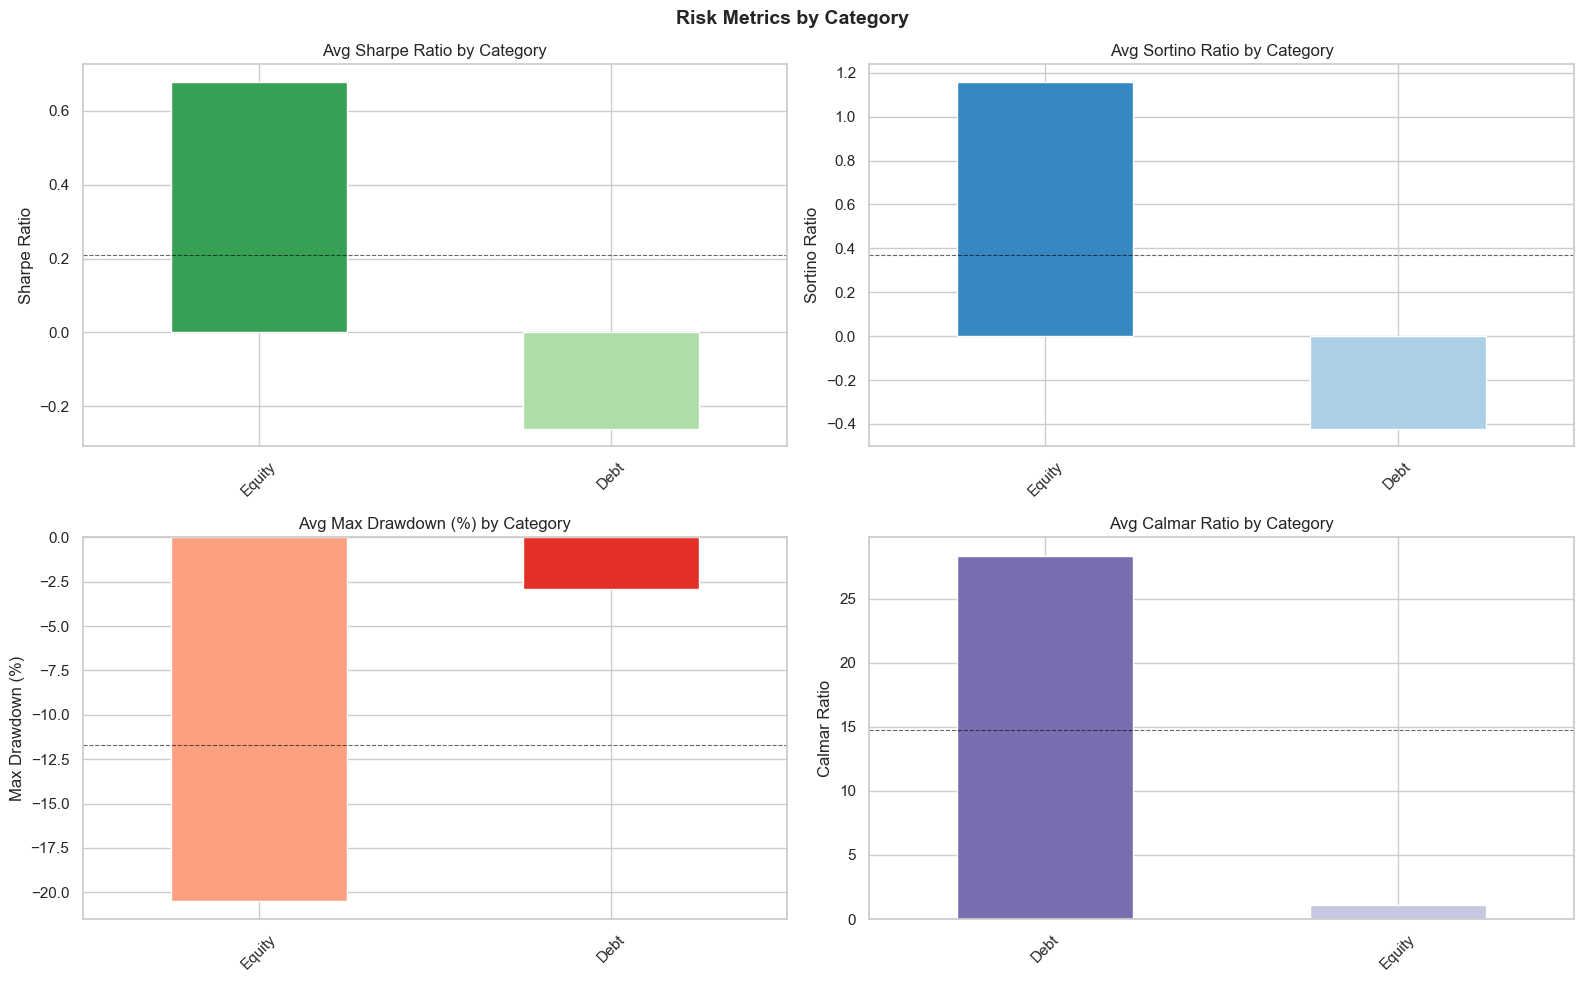

In [11]:
# 6b. Risk metrics side-by-side comparison — 4-panel
metrics  = ["sharpe", "sortino", "max_drawdown", "calmar"]
titles   = ["Sharpe Ratio", "Sortino Ratio", "Max Drawdown (%)", "Calmar Ratio"]
palettes = ["Greens_r", "Blues_r", "Reds", "Purples_r"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, metric, title, pal in zip(axes.flatten(), metrics, titles, palettes):
    data = risk_df.groupby("category")[metric].mean().sort_values(
        ascending=(metric == "max_drawdown"))
    colors_bar = sns.color_palette(pal, len(data))
    data.plot(kind="bar", ax=ax, color=colors_bar, edgecolor="white")
    ax.set_title(f"Avg {title} by Category")
    ax.set_xlabel("")
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(data.mean(), color="black", linestyle="--", linewidth=0.8, alpha=0.6)

plt.suptitle("Risk Metrics by Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

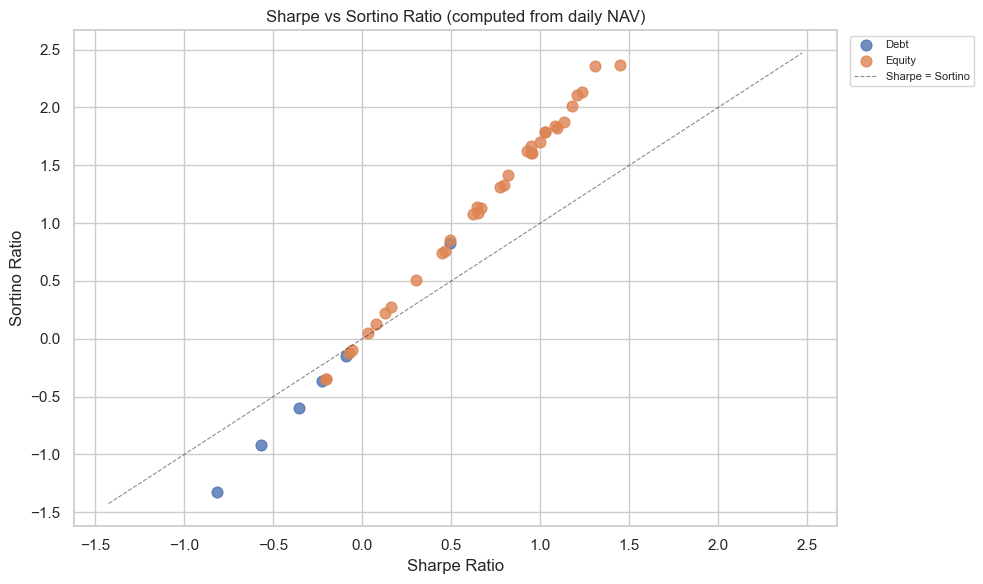

In [12]:
# 6c. Sharpe vs Sortino scatter — colour by category
fig, ax = plt.subplots(figsize=(10, 6))
for cat, grp in risk_df.groupby("category"):
    ax.scatter(grp["sharpe"], grp["sortino"], label=cat, s=60, alpha=0.8)

# Perfect agreement line
lim = [risk_df[["sharpe","sortino"]].min().min()-0.1,
       risk_df[["sharpe","sortino"]].max().max()+0.1]
ax.plot(lim, lim, "k--", linewidth=0.8, alpha=0.5, label="Sharpe = Sortino")
ax.set_title("Sharpe vs Sortino Ratio (computed from daily NAV)")
ax.set_xlabel("Sharpe Ratio")
ax.set_ylabel("Sortino Ratio")
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

---
## 7 — Rolling Performance: 90-Day Rolling Sharpe & Return

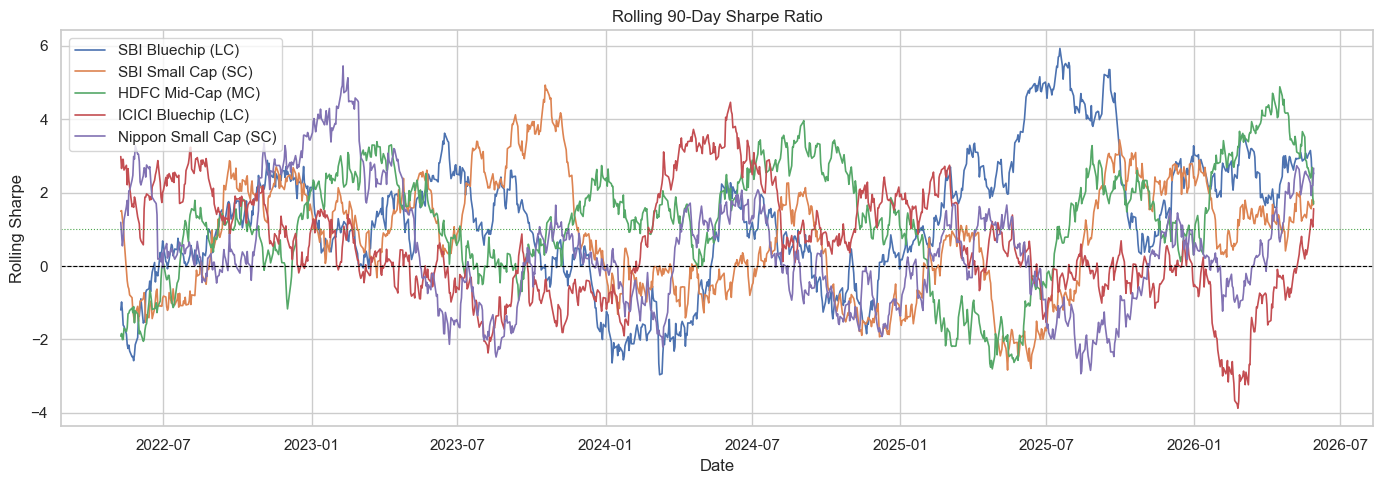

In [13]:
# 7a. Rolling 90-day Sharpe ratio for representative schemes
SAMPLE_CODES = {
    119551: "SBI Bluechip (LC)",
    119598: "SBI Small Cap (SC)",
    100033: "HDFC Mid-Cap (MC)",
    120503: "ICICI Bluechip (LC)",
    118634: "Nippon Small Cap (SC)",
}
WINDOW = 90

fig, ax = plt.subplots(figsize=(14, 5))
for code, label in SAMPLE_CODES.items():
    s = nav[nav["amfi_code"] == code].sort_values("date").dropna(subset=["daily_return_pct"])
    r = s["daily_return_pct"] / 100
    excess = r - RISK_FREE_DAILY
    rolling_sharpe = (excess.rolling(WINDOW).mean() /
                      excess.rolling(WINDOW).std()) * np.sqrt(252)
    ax.plot(s["date"].values, rolling_sharpe.values, label=label, linewidth=1.2)

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.axhline(1, color="green", linestyle=":", linewidth=0.8, alpha=0.7)
ax.set_title(f"Rolling {WINDOW}-Day Sharpe Ratio")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe")
ax.legend()
plt.tight_layout()
plt.show()

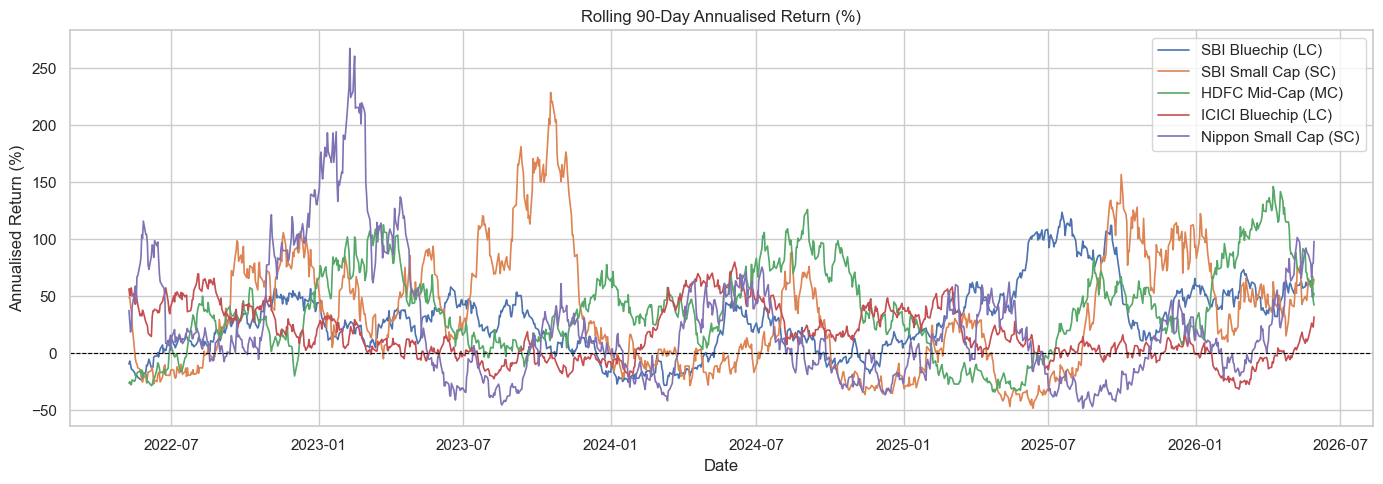

In [14]:
# 7b. Rolling 90-day annualised return
fig, ax = plt.subplots(figsize=(14, 5))
for code, label in SAMPLE_CODES.items():
    s = nav[nav["amfi_code"] == code].sort_values("date").dropna(subset=["daily_return_pct"])
    r = s["daily_return_pct"] / 100
    rolling_ann = r.rolling(WINDOW).apply(lambda x: (1+x).prod()**(252/WINDOW)-1) * 100
    ax.plot(s["date"].values, rolling_ann.values, label=label, linewidth=1.2)

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title(f"Rolling {WINDOW}-Day Annualised Return (%)")
ax.set_xlabel("Date")
ax.set_ylabel("Annualised Return (%)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8 — NAV CAGR Heatmap Across Schemes

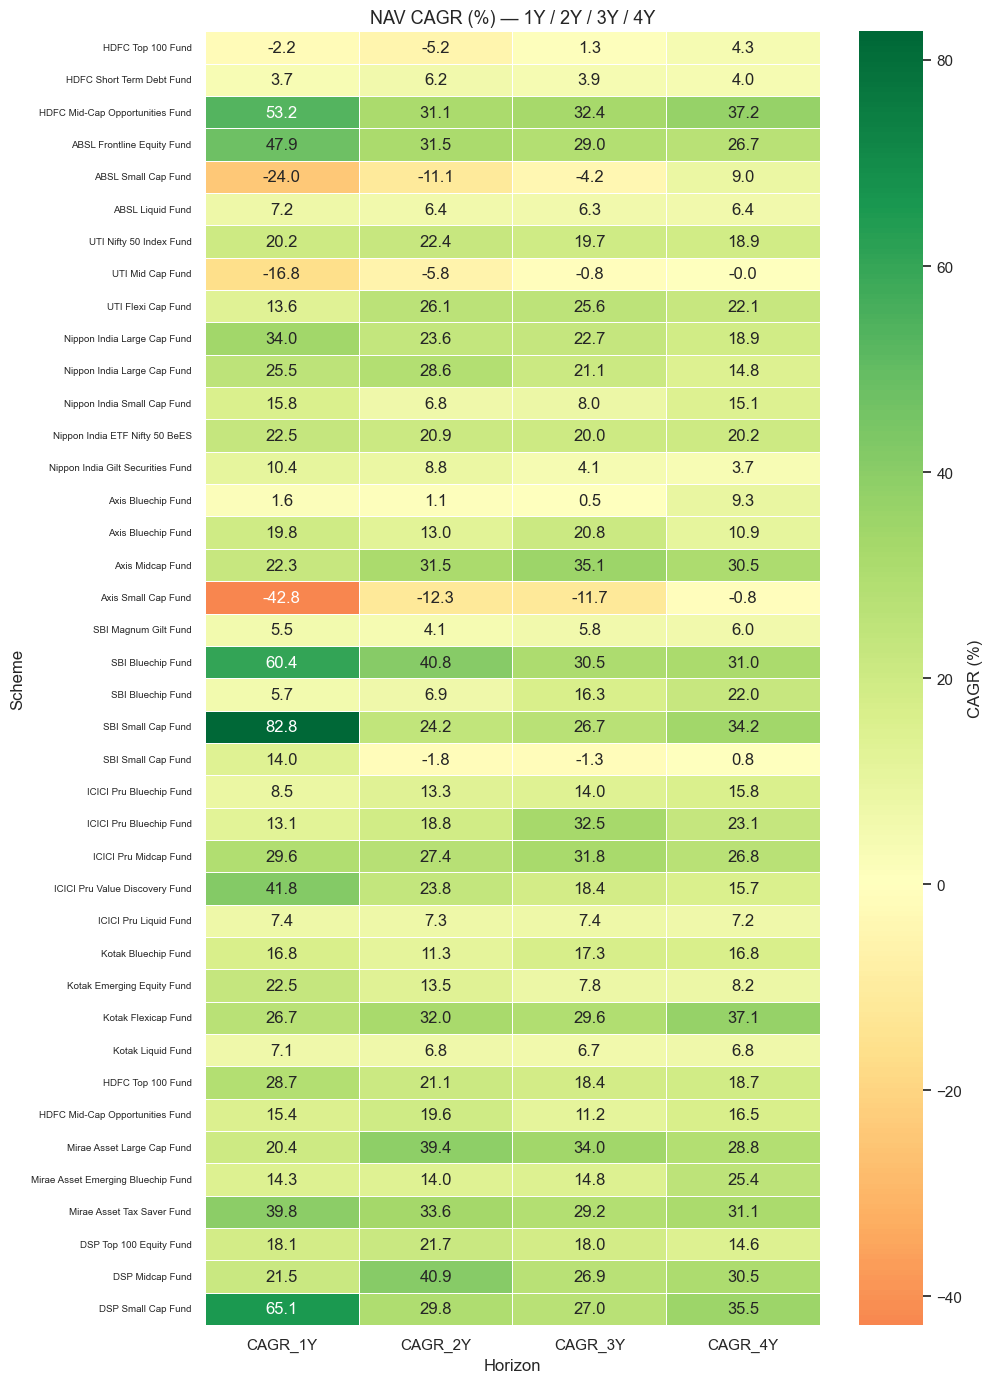

In [15]:
# 8a. Compute 1Y / 2Y / 3Y CAGR directly from NAV series
cagr_rows = []
ref_date  = nav["date"].max()

for code, grp in nav.groupby("amfi_code"):
    grp = grp.sort_values("date").set_index("date")["nav"]
    end_nav = grp.iloc[-1]

    row = {"amfi_code": code,
           "scheme":    nav.loc[nav["amfi_code"] == code, "scheme_name"].iloc[0]
                           .split(" - ")[0].strip()}

    for years, label in [(1, "CAGR_1Y"), (2, "CAGR_2Y"), (3, "CAGR_3Y"), (4, "CAGR_4Y")]:
        target = ref_date - pd.DateOffset(years=years)
        past   = grp[grp.index <= target]
        if len(past) == 0:
            row[label] = np.nan
        else:
            start_nav  = past.iloc[-1]
            row[label] = round((end_nav / start_nav) ** (1/years) - 1, 4) * 100

    cagr_rows.append(row)

cagr_df = pd.DataFrame(cagr_rows).set_index("scheme")
cagr_df = cagr_df.drop(columns="amfi_code")

# Heatmap
fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(cagr_df, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.4, ax=ax,
            cbar_kws={"label": "CAGR (%)"})
ax.set_title("NAV CAGR (%) — 1Y / 2Y / 3Y / 4Y", fontsize=13)
ax.set_xlabel("Horizon")
ax.set_ylabel("Scheme")
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

---
## 9 — Expense Ratio Drag Analysis

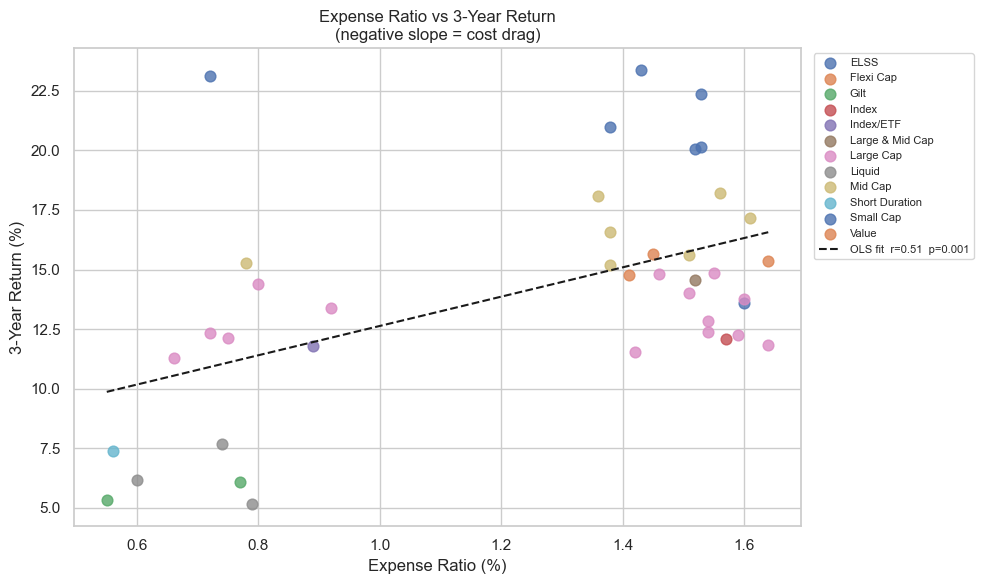

OLS: 3yr Return = 6.15 × Expense_Ratio + 6.49  (r=0.51, p=0.0007)


In [16]:
# 9a. Expense ratio vs 3-year return scatter
fig, ax = plt.subplots(figsize=(10, 6))
for cat, grp in performance.groupby("category"):
    ax.scatter(grp["expense_ratio_pct"], grp["return_3yr_pct"],
               label=cat, s=60, alpha=0.8)

# Regression line
slope, intercept, r, p, _ = linregress(
    performance["expense_ratio_pct"], performance["return_3yr_pct"])
x_line = np.linspace(performance["expense_ratio_pct"].min(),
                     performance["expense_ratio_pct"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, "k--", linewidth=1.5,
        label=f"OLS fit  r={r:.2f}  p={p:.3f}")

ax.set_title("Expense Ratio vs 3-Year Return\n(negative slope = cost drag)")
ax.set_xlabel("Expense Ratio (%)")
ax.set_ylabel("3-Year Return (%)")
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()
print(f"OLS: 3yr Return = {slope:.2f} × Expense_Ratio + {intercept:.2f}  (r={r:.2f}, p={p:.4f})")

---
## 10 — Regular vs Direct Plan Comparison

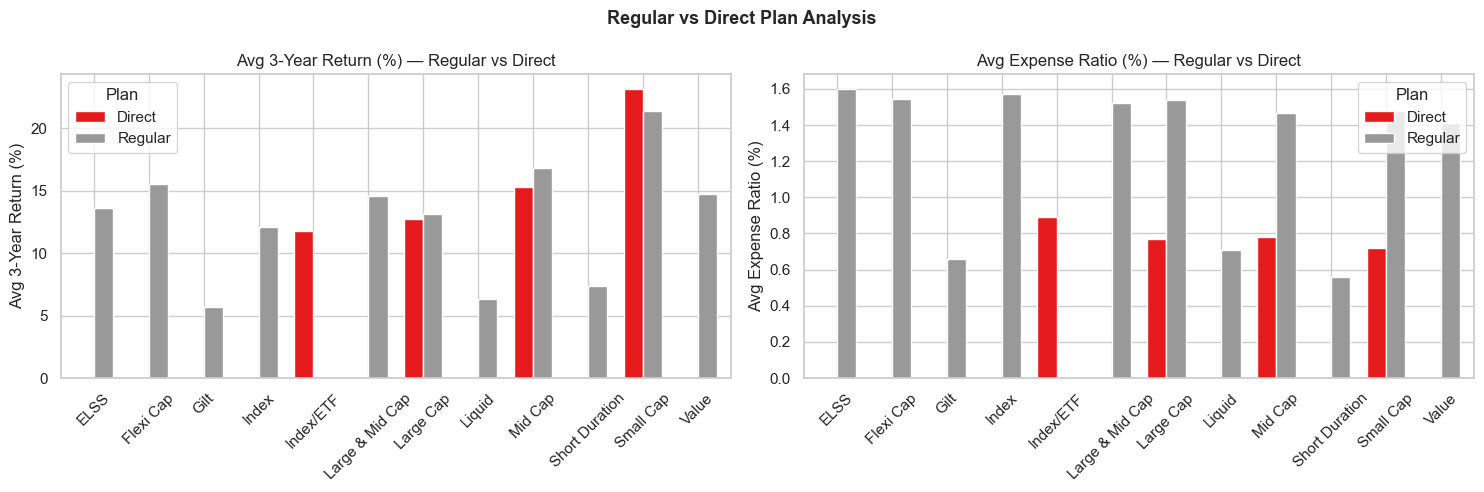

In [17]:
# 10a. Direct vs Regular — return and expense ratio comparison
plan_compare = performance.groupby(["category", "plan"])[
    ["return_1yr_pct", "return_3yr_pct", "return_5yr_pct", "expense_ratio_pct"]
].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col, title in zip(axes,
    ["return_3yr_pct", "expense_ratio_pct"],
    ["Avg 3-Year Return (%)", "Avg Expense Ratio (%)"]):
    pivot = plan_compare.pivot(index="category", columns="plan", values=col)
    pivot.plot(kind="bar", ax=ax, colormap="Set1", edgecolor="white", width=0.7)
    ax.set_title(f"{title} — Regular vs Direct")
    ax.set_xlabel("")
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Plan")

plt.suptitle("Regular vs Direct Plan Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
# 10b. Direct plan advantage — return difference per matched pair
direct_  = performance[performance["plan"] == "Direct"][["fund_house","category","return_3yr_pct","expense_ratio_pct","sharpe_ratio"]]
regular_ = performance[performance["plan"] == "Regular"][["fund_house","category","return_3yr_pct","expense_ratio_pct","sharpe_ratio"]]
paired   = direct_.merge(regular_, on=["fund_house","category"],
                         suffixes=("_direct","_regular"))
paired["return_advantage"]  = paired["return_3yr_pct_direct"]  - paired["return_3yr_pct_regular"]
paired["expense_saving"]    = paired["expense_ratio_pct_regular"] - paired["expense_ratio_pct_direct"]

print("Direct Plan Advantage (3-year return, %):\n")
print(paired[["fund_house","category","return_advantage","expense_saving"]]
      .sort_values("return_advantage", ascending=False).to_string(index=False))
print(f"\nMean return advantage : {paired['return_advantage'].mean():.2f}%")
print(f"Mean expense saving   : {paired['expense_saving'].mean():.2f}%")

Direct Plan Advantage (3-year return, %):

         fund_house  category  return_advantage  expense_saving
ICICI Prudential MF Large Cap              2.87            0.62
   Axis Mutual Fund Large Cap              0.30            0.89
    SBI Mutual Fund Small Cap             -0.25            0.71
    SBI Mutual Fund Large Cap             -1.06            0.88
   HDFC Mutual Fund   Mid Cap             -1.29            0.60
   HDFC Mutual Fund Large Cap             -1.46            0.63
    Nippon India MF Large Cap             -1.67            0.79

Mean return advantage : -0.37%
Mean expense saving   : 0.73%


---
## 11 — Category-Level Performance Ranking

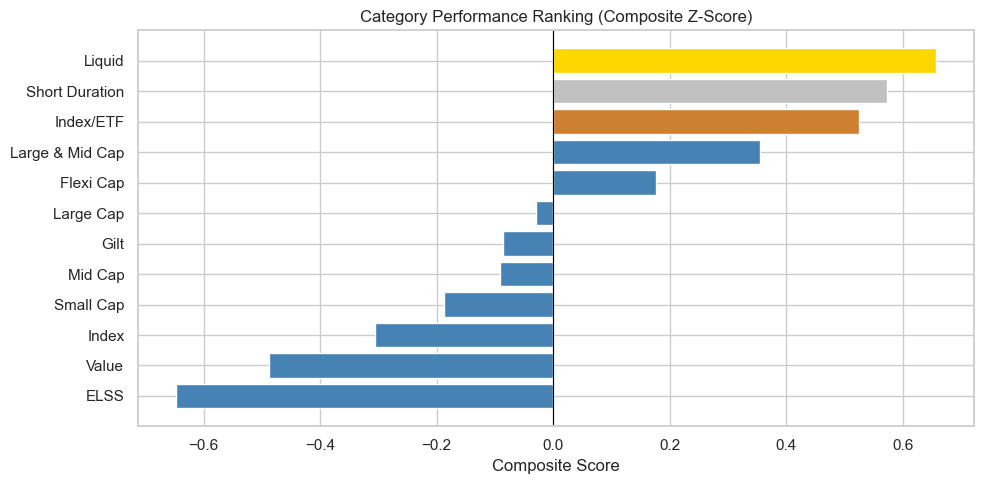

           category  composite_score
1            Liquid             0.66
2    Short Duration             0.57
3         Index/ETF             0.53
4   Large & Mid Cap             0.35
5         Flexi Cap             0.18
6         Large Cap            -0.03
7              Gilt            -0.09
8           Mid Cap            -0.09
9         Small Cap            -0.19
10            Index            -0.31
11            Value            -0.49
12             ELSS            -0.65


In [19]:
# 11a. Composite score: z-score normalise key metrics, average
score_cols = ["return_3yr_pct", "sharpe_ratio", "alpha", "excess_return"]
drag_cols  = ["std_dev_ann_pct", "max_drawdown_pct", "expense_ratio_pct"]

perf_z = performance.copy()
for col in score_cols:
    perf_z[f"z_{col}"] = (perf_z[col] - perf_z[col].mean()) / perf_z[col].std()
for col in drag_cols:
    # Invert drag: lower is better → negate z-score
    perf_z[f"z_{col}"] = -((perf_z[col] - perf_z[col].mean()) / perf_z[col].std())

z_cols = [f"z_{c}" for c in score_cols + drag_cols]
perf_z["composite_score"] = perf_z[z_cols].mean(axis=1).round(3)

# Category ranking
cat_rank = perf_z.groupby("category")["composite_score"].mean()\
                  .sort_values(ascending=False).reset_index()
cat_rank.index += 1

fig, ax = plt.subplots(figsize=(10, 5))
colors_rank = ["gold" if i==1 else "silver" if i==2 else "#cd7f32" if i==3
               else "steelblue" for i in range(1, len(cat_rank)+1)]
ax.barh(cat_rank["category"][::-1], cat_rank["composite_score"][::-1],
        color=colors_rank[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Category Performance Ranking (Composite Z-Score)")
ax.set_xlabel("Composite Score")
plt.tight_layout()
plt.show()
print(cat_rank.to_string())

---
## 12 — Performance Consistency: Win-Rate Analysis

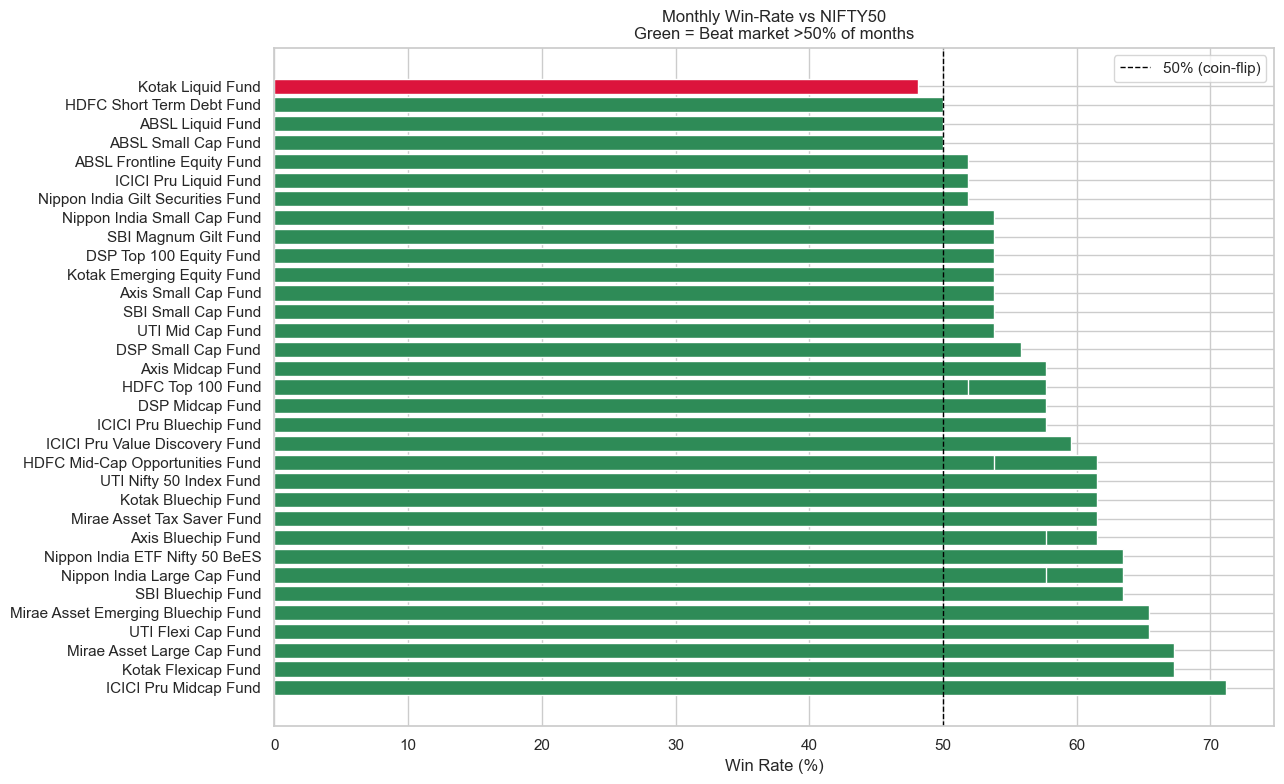


Schemes beating NIFTY50 > 50% of months: 36/40


In [20]:
# 12a. Monthly win-rate — % of months scheme beat NIFTY50
nifty_monthly = (
    bench_wide["NIFTY50"]
    .resample("ME").last()
    .pct_change()
    .mul(100)
    .rename("nifty_monthly")
)

win_rate_rows = []
for code, grp in nav.groupby("amfi_code"):
    monthly = (
        grp.set_index("date")["nav"]
        .resample("ME").last()
        .pct_change()
        .mul(100)
    )
    merged_m = pd.concat([monthly, nifty_monthly], axis=1).dropna()
    if len(merged_m) < 6:
        continue
    wins     = (merged_m["nav"] > merged_m["nifty_monthly"]).sum()
    win_rate = wins / len(merged_m) * 100
    win_rate_rows.append({
        "amfi_code":   code,
        "scheme_name": grp["scheme_name"].iloc[0],
        "category":    grp["category"].iloc[0],
        "plan":        grp["plan"].iloc[0],
        "win_rate":    round(win_rate, 1),
        "months":      len(merged_m),
    })

winrate_df = pd.DataFrame(win_rate_rows).sort_values("win_rate", ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))
colors_wr = ["seagreen" if w >= 50 else "crimson" for w in winrate_df["win_rate"]]
ax.barh(winrate_df["scheme_name"].str.split(" - ").str[0],
        winrate_df["win_rate"], color=colors_wr, edgecolor="white")
ax.axvline(50, color="black", linestyle="--", linewidth=1,
           label="50% (coin-flip)")
ax.set_title("Monthly Win-Rate vs NIFTY50\nGreen = Beat market >50% of months",
             fontsize=12)
ax.set_xlabel("Win Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nSchemes beating NIFTY50 > 50% of months: "
      f"{(winrate_df['win_rate']>50).sum()}/{len(winrate_df)}")

---
## 13 — Summary League Table

In [21]:
# Merge all computed metrics into one master table
league = (
    risk_df[["amfi_code","scheme_name","category","plan",
             "ann_return","ann_vol","sharpe","sortino","max_drawdown","calmar"]]
    .merge(beta_df[["amfi_code","ols_beta","r_squared"]], on="amfi_code", how="left")
    .merge(winrate_df[["amfi_code","win_rate"]], on="amfi_code", how="left")
    .merge(performance[["amfi_code","excess_return","morningstar_rating",
                        "expense_ratio_pct"]], on="amfi_code", how="left")
    .sort_values("sharpe", ascending=False)
    .reset_index(drop=True)
)
league.index += 1

print("=" * 80)
print("  PERFORMANCE ANALYTICS — LEAGUE TABLE (sorted by Sharpe)")
print("=" * 80)
print(league[["scheme_name","category","plan",
              "ann_return","sharpe","sortino","max_drawdown",
              "calmar","ols_beta","win_rate","excess_return"]]
      .to_string())

# Save to processed for downstream use
league.to_csv("../data/processed/performance_league.csv", index=False)
print("\nLeague table saved → data/processed/performance_league.csv")

  PERFORMANCE ANALYTICS — LEAGUE TABLE (sorted by Sharpe)
                                              scheme_name category     plan  ann_return  sharpe  sortino  max_drawdown  calmar  ols_beta  win_rate  excess_return
1           Mirae Asset Large Cap Fund - Regular - Growth   Equity  Regular       29.74    1.45     2.37        -11.27    2.64     -0.03     67.30           1.62
2                  Kotak Flexicap Fund - Regular - Growth   Equity  Regular       29.68    1.31     2.35        -12.97    2.29     -0.01     67.30           1.85
3           Mirae Asset Tax Saver Fund - Regular - Growth   Equity  Regular       30.67    1.24     2.14        -16.40    1.87     -0.01     61.50           0.54
4               SBI Bluechip Fund - Regular Plan - Growth   Equity  Regular       24.80    1.21     2.11        -15.01    1.65     -0.06     63.50           0.87
5                ICICI Pru Midcap Fund - Regular - Growth   Equity  Regular       31.51    1.18     2.01        -18.19    1.73     -

In [22]:
# Styled top-20 table
display_cols = ["scheme_name","category","plan","ann_return","ann_vol",
                "sharpe","max_drawdown","win_rate","excess_return",
                "morningstar_rating"]
league[display_cols].head(20).style\
    .background_gradient(subset=["sharpe"], cmap="Greens")\
    .background_gradient(subset=["ann_return"], cmap="Blues")\
    .background_gradient(subset=["max_drawdown"], cmap="Reds_r")\
    .background_gradient(subset=["win_rate"], cmap="YlGn")\
    .format({
        "ann_return":  "{:.2f}%",
        "ann_vol":     "{:.2f}%",
        "sharpe":      "{:.3f}",
        "max_drawdown":"{:.2f}%",
        "win_rate":    "{:.1f}%",
        "excess_return":"{:.2f}%",
    })

,scheme_name,category,plan,ann_return,ann_vol,sharpe,max_drawdown,win_rate,excess_return,morningstar_rating
1,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Regular,29.74%,14.19%,1.449,-11.27%,67.3%,1.62%,5
2,Kotak Flexicap Fund - Regular - Growth,Equity,Regular,29.68%,15.88%,1.307,-12.97%,67.3%,1.85%,5
3,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,Regular,30.67%,17.67%,1.235,-16.40%,61.5%,0.54%,5
4,SBI Bluechip Fund - Regular Plan - Growth,Equity,Regular,24.80%,13.74%,1.209,-15.01%,63.5%,0.87%,4
5,ICICI Pru Midcap Fund - Regular - Growth,Equity,Regular,31.51%,19.28%,1.181,-18.19%,71.2%,0.89%,3
6,DSP Midcap Fund - Regular - Growth,Equity,Regular,28.41%,17.74%,1.133,-17.25%,57.7%,1.02%,4
7,HDFC Mid-Cap Opportunities Fund - Regular - Growth,Equity,Regular,28.93%,18.93%,1.094,-16.22%,61.5%,0.95%,5
8,Nippon India Large Cap Fund - Regular - Growth,Equity,Regular,23.12%,14.14%,1.082,-17.41%,63.5%,0.86%,4
9,ABSL Frontline Equity Fund - Regular - Growth,Equity,Regular,22.63%,14.56%,1.028,-11.29%,51.9%,1.34%,5
10,ICICI Pru Bluechip Fund - Direct - Growth,Equity,Direct,22.39%,14.36%,1.027,-12.59%,57.7%,0.88%,3


In [23]:
print("=" * 60)
print("  PERFORMANCE ANALYTICS — KEY FINDINGS")
print("=" * 60)
best_sharpe  = league.loc[league["sharpe"].idxmax()]
best_return  = league.loc[league["ann_return"].idxmax()]
lowest_dd    = league.loc[league["max_drawdown"].idxmax()]   # least negative
best_winrate = league.loc[league["win_rate"].idxmax()]
print(f"  Best Sharpe      : {best_sharpe['scheme_name'].split(chr(45))[0].strip()} ({best_sharpe['sharpe']:.2f})")
print(f"  Best Ann. Return : {best_return['scheme_name'].split(chr(45))[0].strip()} ({best_return['ann_return']:.1f}%)")
print(f"  Lowest Drawdown  : {lowest_dd['scheme_name'].split(chr(45))[0].strip()} ({lowest_dd['max_drawdown']:.1f}%)")
print(f"  Best Win-Rate    : {best_winrate['scheme_name'].split(chr(45))[0].strip()} ({best_winrate['win_rate']:.1f}%)")
print(f"  Schemes > 50% win-rate vs NIFTY50: {(league['win_rate']>50).sum()}/{len(league)}")
print(f"  Avg Direct plan return premium   : see Cell 10b")
print("=" * 60)

  PERFORMANCE ANALYTICS — KEY FINDINGS
  Best Sharpe      : Mirae Asset Large Cap Fund (1.45)
  Best Ann. Return : ICICI Pru Midcap Fund (31.5%)
  Lowest Drawdown  : ICICI Pru Liquid Fund (-0.1%)
  Best Win-Rate    : ICICI Pru Midcap Fund (71.2%)
  Schemes > 50% win-rate vs NIFTY50: 36/40
  Avg Direct plan return premium   : see Cell 10b
